<a href="https://colab.research.google.com/github/kfafa2018-ux/Computer-Vision/blob/main/Week_5_Assignment_Thresholding_%26_Enhancement.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [5]:
import matplotlib.pyplot as plt

The first thing I did was add google drive to the notebook so I could gather an image for the project.

In [6]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


Binary (Global) Thresholding
(Slide 20) If the pixel value is greater than the
threshold, it is considered a white pixel, or
else it is considered a black pixel.

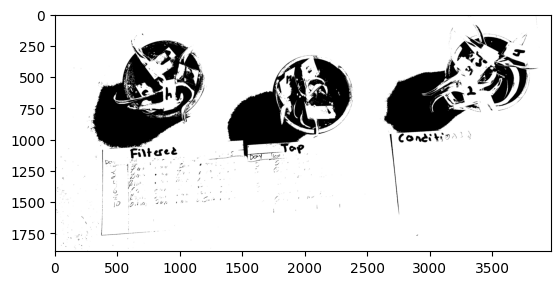

In [14]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

img = cv2.imread("/content/drive/MyDrive/IMG_1681.jpeg", cv2.IMREAD_GRAYSCALE)

if img is None:
    print("Error: Image 'dog.jpg' not found. Please upload the image file or provide the correct path.")
else:
    _, segmented1 = cv2.threshold(img, 75, 150, cv2.THRESH_BINARY)
    # The max threshold is 150 and the min is 75

    # Convert segmented1 to a float type and specify cmap for proper display
    plt.imshow(segmented1.astype(np.float32), cmap='gray')

[[0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]
 [1 1 0 ... 0 0 0]
 ...
 [0 0 0 ... 1 1 1]
 [0 0 0 ... 1 1 1]
 [0 0 0 ... 1 1 1]]


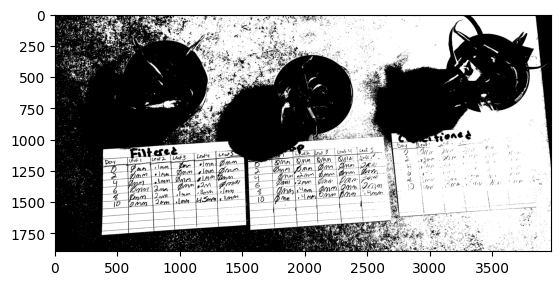

In [15]:
if img is not None:
    _, segmented1 = cv2.threshold(img, 150,1,cv2.THRESH_BINARY)
    print(segmented1)
    plt.imshow(segmented1, cmap=plt.cm.gray)
else:
    print("Image 'dog.jpg' not loaded. Please upload the image file.")

[[1. 1. 1. ... 0. 0. 0.]
 [1. 1. 1. ... 0. 0. 0.]
 [1. 1. 1. ... 0. 0. 0.]
 ...
 [0. 0. 0. ... 1. 1. 1.]
 [0. 0. 0. ... 1. 1. 1.]
 [0. 0. 0. ... 1. 1. 1.]]


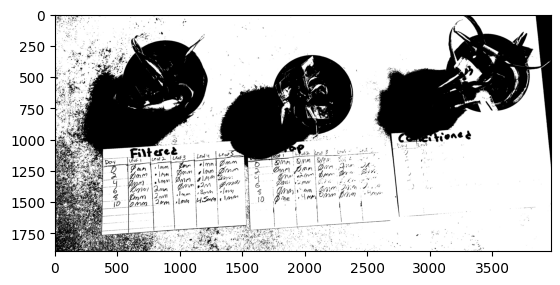

In [9]:
if img is not None:
    _, segmented2 = cv2.threshold(img, 127,1,cv2.THRESH_BINARY)
    segmented2 = segmented2.astype(dtype='f')
    print(segmented2)
    plt.imshow(segmented1, cmap=plt.cm.gray)
    # cv2.waitKey(0)
else:
    print("Image 'dog.jpg' not loaded. Please upload the image file.")

This is Otsus Threshold (slide 26) This does not require the setting of parameters as it uses a probability function.

125.0
[[1. 1. 1. ... 0. 0. 0.]
 [1. 1. 1. ... 0. 0. 0.]
 [1. 1. 1. ... 0. 0. 0.]
 ...
 [0. 0. 0. ... 1. 1. 1.]
 [0. 0. 0. ... 1. 1. 1.]
 [0. 0. 0. ... 1. 1. 1.]]


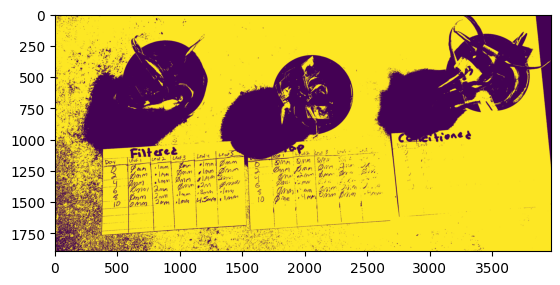

In [10]:
if img is not None:
    thresh, segmented2 = cv2.threshold(img, 127,1,cv2.THRESH_OTSU)
    segmented2 = segmented2.astype(dtype='f')
    print(thresh)
    print(segmented2)
    plt.imshow(segmented2)
    # cv2.waitKey(0)
    # cv2.destroyAllWindows()
else:
    print("Image 'dog.jpg' not loaded. Please upload the image file.")

Adaptive Mean Thresholding (slide 24) Uses a standard mean
calculation of the surrounding
pixel values intensities (color)

[[  0 255 255 ... 255 255 255]
 [  0 255 255 ... 255 255 255]
 [255 255 255 ... 255 255 255]
 ...
 [255   0   0 ... 255 255 255]
 [  0 255 255 ... 255 255 255]
 [255 255 255 ... 255 255 255]]


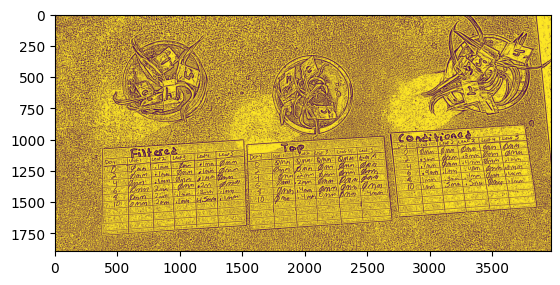

In [11]:
if img is not None:
    segmented4 = cv2.adaptiveThreshold(img,255,cv2.ADAPTIVE_THRESH_MEAN_C, cv2.THRESH_BINARY,15,2)
    print(segmented4)
    plt.imshow(segmented4)
    # cv2.waitKey(0)

    # cv2.waitKey(0)
else:
    print("Image 'dog.jpg' not loaded. Please upload the image file.")

Adaptive Gaussian Thresholding (slide 24) Uses a weighted mean
calculation where the pixel
intensities closest to the center
are counted for weighted mean.


[[  0 255 255 ... 255 255 255]
 [  0   0 255 ... 255 255 255]
 [255 255 255 ... 255 255 255]
 ...
 [255 255   0 ... 255 255 255]
 [255 255 255 ... 255 255 255]
 [255 255 255 ... 255 255 255]]


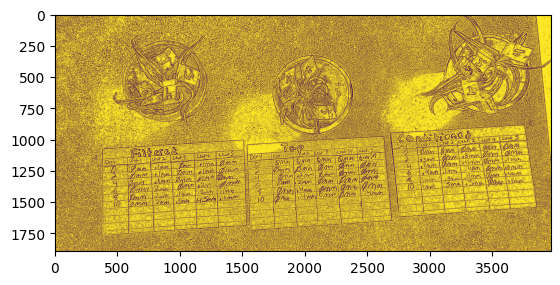

In [12]:
if img is not None:
    segmented5 = cv2.adaptiveThreshold(img,255,cv2.ADAPTIVE_THRESH_GAUSSIAN_C, cv2.THRESH_BINARY,15,2)
    print(segmented5)
    plt.imshow(segmented5)
else:
    print("Image 'dog.jpg' not loaded. Please upload the image file.")

## Thresholding Techniques Used:

The notebook demonstrates several image thresholding techniques using OpenCV:

1.  **Simple Binary Thresholding (`cv2.THRESH_BINARY`)**: This method applies a fixed threshold value to segment the image. Pixels with intensity values above the threshold are set to one value (e.g., 255 or 1), and pixels below are set to another (e.g., 0). This is seen in cells where `cv2.threshold` is used with `cv2.THRESH_BINARY`.

2.  **Otsu's Thresholding (`cv2.THRESH_OTSU`)**: This is an automatic thresholding method where the algorithm calculates the optimal threshold value by minimizing the intra-class variance of the two classes (foreground and background). This is used with `cv2.threshold(img, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)` or directly as `cv2.threshold(img, 127, 1, cv2.THRESH_OTSU)` as shown in one of your cells.

3.  **Adaptive Mean Thresholding (`cv2.ADAPTIVE_THRESH_MEAN_C`)**: Instead of using a global threshold for the entire image, adaptive thresholding calculates a threshold for small regions of the image. For `ADAPTIVE_THRESH_MEAN_C`, the threshold value is the mean of the neighborhood area minus a constant C. This is demonstrated using `cv2.adaptiveThreshold`.

4.  **Adaptive Gaussian Thresholding (`cv2.ADAPTIVE_THRESH_GAUSSIAN_C`)**: Similar to adaptive mean thresholding, but the threshold value is the weighted sum of the neighborhood values where weights are a Gaussian window. This is also demonstrated using `cv2.adaptiveThreshold`.

## Image Segmentation

Image segmentation is the process of partitioning a digital image into multiple segments (sets of pixels, also known as superpixels). The goal of segmentation is to simplify and/or change the representation of an image into something more meaningful and easier to analyze.

The thresholding techniques demonstrated in this notebook (Binary, Otsu's, Adaptive Mean, and Adaptive Gaussian) are all forms of image segmentation. They work by classifying pixels into different groups (e.g., foreground and background) based on their intensity values, thereby segmenting the image.